# Steps 1-3: EDA, Feature Engineering & Data Preparation

## Overview
This notebook covers **Steps 1–3** of the Instacart reorder prediction pipeline:

1. **Exploratory Data Analysis** — user, product, and interaction-level insights
2. **Feature Engineering** — user, product, and user×product features
3. **Data Preparation** — train/test split, imputation, scaling, and saving artefacts

**Prediction target:** `reordered` — whether a user will reorder a given product in their next order.

---

## Setup Instructions

### Prerequisites
- Python 3.8+ installed
- VS Code with the **Python** and **Jupyter** extensions installed

### 1. Get the project files
Place all notebook files in a single project folder, e.g. `DTSC870/`.

### 2. Download the dataset
Download the Instacart dataset from Kaggle:
https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset

Place the downloaded zip file in the **same folder as this notebook**.
The notebook expects the Kaggle default filename `archive.zip`.
If your file has a different name, update `ZIP_PATH` in the Configuration cell below.

### 3. Create and activate a virtual environment
Open a terminal inside VS Code (**Terminal → New Terminal**) and run:

```bash
# Create the virtual environment
python -m venv venv

# Activate it — Windows:
venv\Scripts\activate

# Activate it — Mac/Linux:
source venv/bin/activate
```

You should see `(venv)` appear at the start of your terminal prompt.

### 4. Install dependencies
With the virtual environment active, run:
```bash
pip install -r requirements.txt
```

### 5. Select the kernel in VS Code
Click the kernel selector in the top-right corner of this notebook.
Choose the interpreter inside your `venv` folder — it will show a path ending in
`venv\Scripts\python.exe` (Windows) or `venv/bin/python` (Mac/Linux).

---

## Version History

| Version | Environment | Notes |
|---|---|---|
| v1 | Colab | Initial notebook |
| v2 | Colab | Attempted leakage fix: dropped `up_last_order_number`, `up_first_order_number`, `up_times_reordered` from `FEATURE_COLS`. Leakage persisted — ROC-AUC = 1.0 in Step 4. |
| v3 | Colab | Correct leakage fix: recomputed all `up_` features over prior history **excluding the most recent order**. Added explicit `up_in_last_order` feature. Colab free-tier RAM (~12 GB) was exhausted twice during Section 3.4, crashing the session. |
| v4 | VS Code (local) | Migrated from Colab to local VS Code to eliminate RAM constraints. All Colab-specific code removed. Paths updated for local filesystem. Memory-safe pattern (`del` + `gc.collect()`) retained. GitHub-friendly setup added. |


## 0. Configuration & Imports

In [2]:
import zipfile, os, gc, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# ── Paths ─────────────────────────────────────────────────────────────────────
# ZIP_PATH     : Kaggle default filename — update if yours differs
# DATA_DIR     : folder where the zip will be extracted
# ARTEFACT_DIR : folder where prepared parquet/pkl files will be saved

ZIP_PATH     = "../data/archive.zip"
DATA_DIR     = "../data/instacart_data"
ARTEFACT_DIR = "../prepared_data"

os.makedirs(ARTEFACT_DIR, exist_ok=True)

print("Configuration complete.")
print(f"  ZIP_PATH     : {os.path.abspath(ZIP_PATH)}")
print(f"  DATA_DIR     : {os.path.abspath(DATA_DIR)}")
print(f"  ARTEFACT_DIR : {os.path.abspath(ARTEFACT_DIR)}")


Configuration complete.
  ZIP_PATH     : /Users/martinmilon/Documents/DTSC870/data/archive.zip
  DATA_DIR     : /Users/martinmilon/Documents/DTSC870/data/instacart_data
  ARTEFACT_DIR : /Users/martinmilon/Documents/DTSC870/prepared_data


## 1. Load Data

The zip file is extracted on first run. If the data folder already exists,
extraction is skipped so re-running the notebook is fast.


In [3]:
if not os.path.exists(DATA_DIR):
    print(f"Extracting {ZIP_PATH} ...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print("Extraction complete.")
else:
    print(f"'{DATA_DIR}' already exists — skipping extraction.")

# locate CSV files (handles nested subfolders that Kaggle zips sometimes produce)
csv_files = {}
for root, dirs, files in os.walk(DATA_DIR):
    for fname in files:
        if fname.endswith('.csv'):
            csv_files[fname] = os.path.join(root, fname)

print(f"\nFound {len(csv_files)} CSV files:")
for k in sorted(csv_files):
    print(f"  {k}")

products             = pd.read_csv(csv_files['products.csv'])
aisles               = pd.read_csv(csv_files['aisles.csv'])
departments          = pd.read_csv(csv_files['departments.csv'])
orders               = pd.read_csv(csv_files['orders.csv'])
order_products_prior = pd.read_csv(csv_files['order_products__prior.csv'])
order_products_train = pd.read_csv(csv_files['order_products__train.csv'])

# enrich products with aisle and department names
products = (products
            .merge(aisles,      on='aisle_id',     how='left')
            .merge(departments, on='department_id', how='left'))

print("\nTable shapes:")
for name, df in [('products', products), ('aisles', aisles),
                 ('departments', departments), ('orders', orders),
                 ('order_products_prior', order_products_prior),
                 ('order_products_train', order_products_train)]:
    print(f"  {name:<30} {df.shape}")


'../data/instacart_data' already exists — skipping extraction.

Found 6 CSV files:
  aisles.csv
  departments.csv
  order_products__prior.csv
  order_products__train.csv
  orders.csv
  products.csv

Table shapes:
  products                       (49688, 6)
  aisles                         (134, 2)
  departments                    (21, 2)
  orders                         (3421083, 7)
  order_products_prior           (32434489, 4)
  order_products_train           (1384617, 4)


## 2. Exploratory Data Analysis

EDA is organised around three levels of analysis relevant to our prediction task:
- **User level** — who is buying and how frequently?
- **Product level** — which products are popular and which are reordered?
- **User x Product level** — how does a user's history with a product predict future reorders?

We also examine the target variable distribution to anticipate class-imbalance issues.


### 2.1 Target Variable — `reordered` (train set)

The target is mildly imbalanced: ~60% of train-set order-product pairs are reorders.
Both models will use imbalance-handling strategies: `class_weight='balanced'` for
Logistic Regression and `scale_pos_weight` for LightGBM.


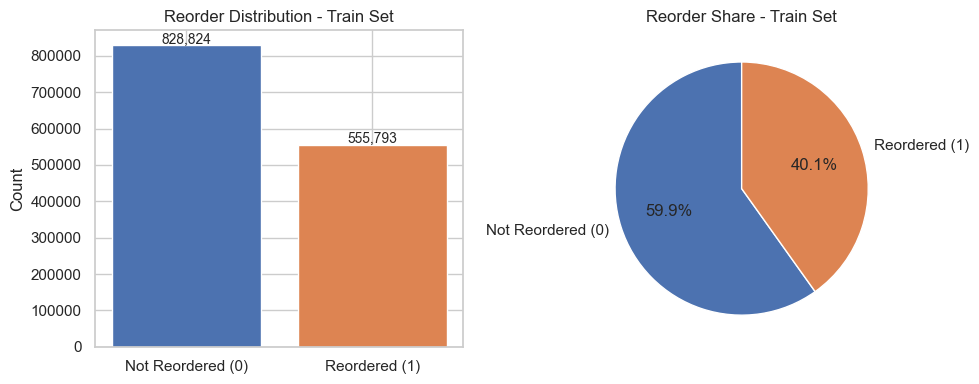

Reordered=1 : 828,824  (59.9%)
Reordered=0 : 555,793  (40.1%)
Imbalance ratio (0:1) : 0.67


In [4]:
counts = order_products_train['reordered'].value_counts()
labels = ['Not Reordered (0)', 'Reordered (1)']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Reorder Distribution - Train Set')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Reorder Share - Train Set')

plt.tight_layout()
plt.show()

print(f"Reordered=1 : {counts[1]:,}  ({counts[1]/counts.sum()*100:.1f}%)")
print(f"Reordered=0 : {counts[0]:,}  ({counts[0]/counts.sum()*100:.1f}%)")
print(f"Imbalance ratio (0:1) : {counts[0]/counts[1]:.2f}")


### 2.2 User-Level Analysis

Users with more orders and shorter reorder intervals tend to show stronger product loyalty.


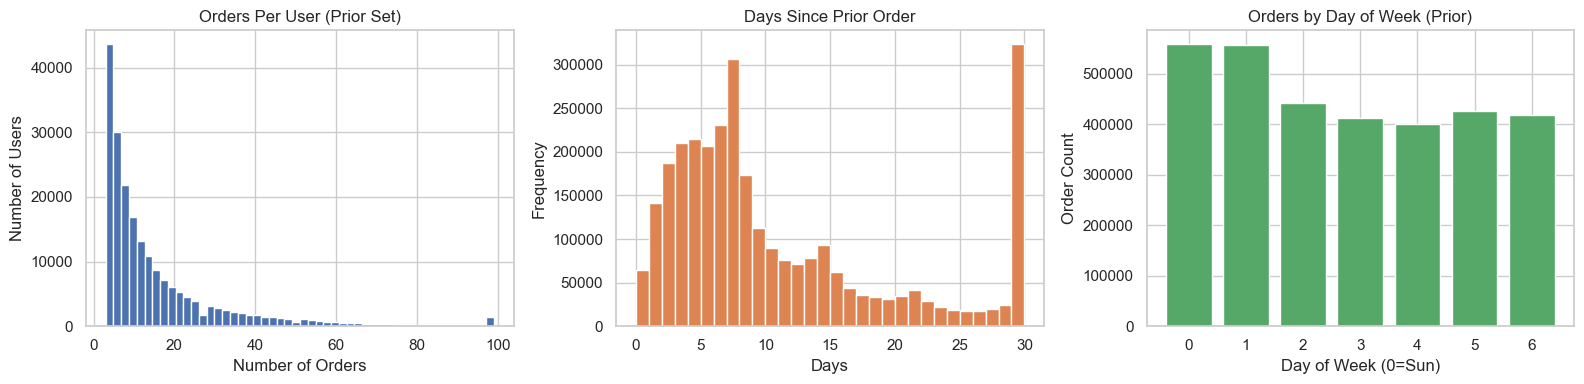

Orders Per User Summary (Prior Set):
count    206,209.00
mean          15.59
std           16.65
min            3.00
25%            5.00
50%            9.00
75%           19.00
max           99.00
Name: order_id, dtype: str


In [5]:
prior_orders = orders[orders['eval_set'] == 'prior']
train_orders = orders[orders['eval_set'] == 'train']

orders_per_user = prior_orders.groupby('user_id')['order_id'].nunique()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(orders_per_user, bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Orders Per User (Prior Set)')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Users')

dspo = prior_orders['days_since_prior_order'].dropna()
axes[1].hist(dspo, bins=30, color='#DD8452', edgecolor='white')
axes[1].set_title('Days Since Prior Order')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Frequency')

dow_counts = prior_orders['order_dow'].value_counts().sort_index()
axes[2].bar(dow_counts.index, dow_counts.values, color='#55A868', edgecolor='white')
axes[2].set_title('Orders by Day of Week (Prior)')
axes[2].set_xlabel('Day of Week (0=Sun)')
axes[2].set_ylabel('Order Count')

plt.tight_layout()
plt.show()

print("Orders Per User Summary (Prior Set):")
print(orders_per_user.describe().apply('{:,.2f}'.format))


### 2.3 Product-Level Analysis

Product reorder rate and popularity are among the strongest predictors.


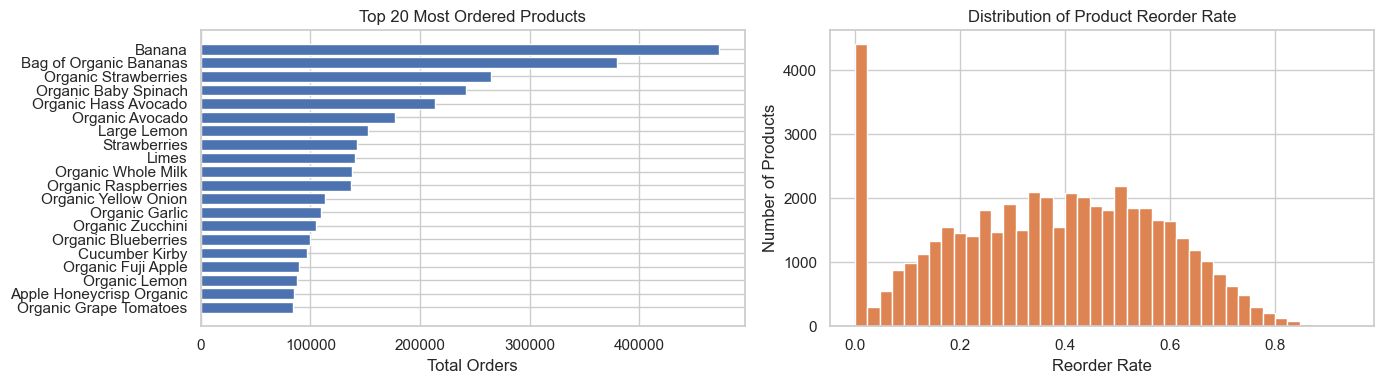

Product Reorder Rate Summary:
count    49,677.0000
mean          0.3665
std           0.2081
min           0.0000
25%           0.2081
50%           0.3766
75%           0.5293
max           0.9412
Name: reorder_rate, dtype: str


In [6]:
prod_stats = order_products_prior.groupby('product_id').agg(
    total_orders   = ('order_id', 'count'),
    total_reorders = ('reordered', 'sum')
).reset_index()
prod_stats['reorder_rate'] = prod_stats['total_reorders'] / prod_stats['total_orders']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top20 = prod_stats.nlargest(20, 'total_orders').merge(
    products[['product_id', 'product_name']], on='product_id')
axes[0].barh(top20['product_name'], top20['total_orders'], color='#4C72B0')
axes[0].set_title('Top 20 Most Ordered Products')
axes[0].set_xlabel('Total Orders')
axes[0].invert_yaxis()

axes[1].hist(prod_stats['reorder_rate'], bins=40, color='#DD8452', edgecolor='white')
axes[1].set_title('Distribution of Product Reorder Rate')
axes[1].set_xlabel('Reorder Rate')
axes[1].set_ylabel('Number of Products')

plt.tight_layout()
plt.show()

print("Product Reorder Rate Summary:")
print(prod_stats['reorder_rate'].describe().apply('{:,.4f}'.format))


### 2.4 Add-to-Cart Position vs. Reorder Rate

Products added to the cart earlier tend to be reordered more often.
Habitual, high-priority items are placed first.


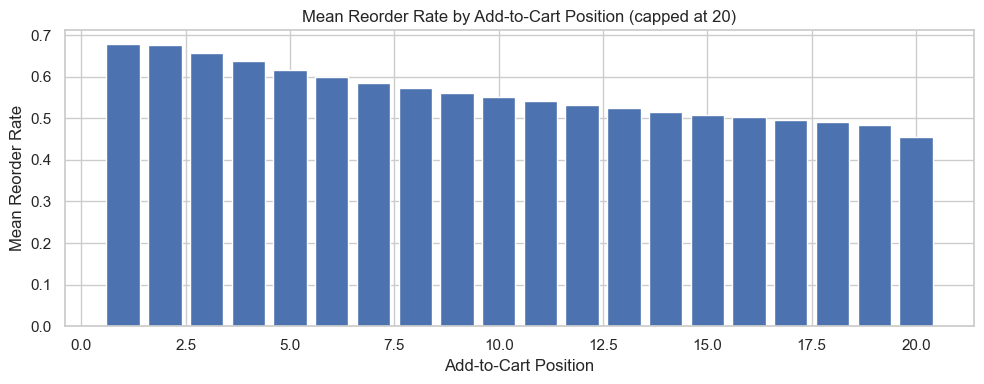

In [7]:
atc = order_products_prior.copy()
atc['position_bin'] = atc['add_to_cart_order'].clip(upper=20)
atc_reorder = atc.groupby('position_bin')['reordered'].mean().reset_index()
del atc

plt.figure(figsize=(10, 4))
plt.bar(atc_reorder['position_bin'], atc_reorder['reordered'],
        color='#4C72B0', edgecolor='white')
plt.title('Mean Reorder Rate by Add-to-Cart Position (capped at 20)')
plt.xlabel('Add-to-Cart Position')
plt.ylabel('Mean Reorder Rate')
plt.tight_layout()
plt.show()


### 2.5 Reorder Rate by Department

Produce and Dairy Eggs have structurally higher reorder rates due to their
perishable, consumable nature.


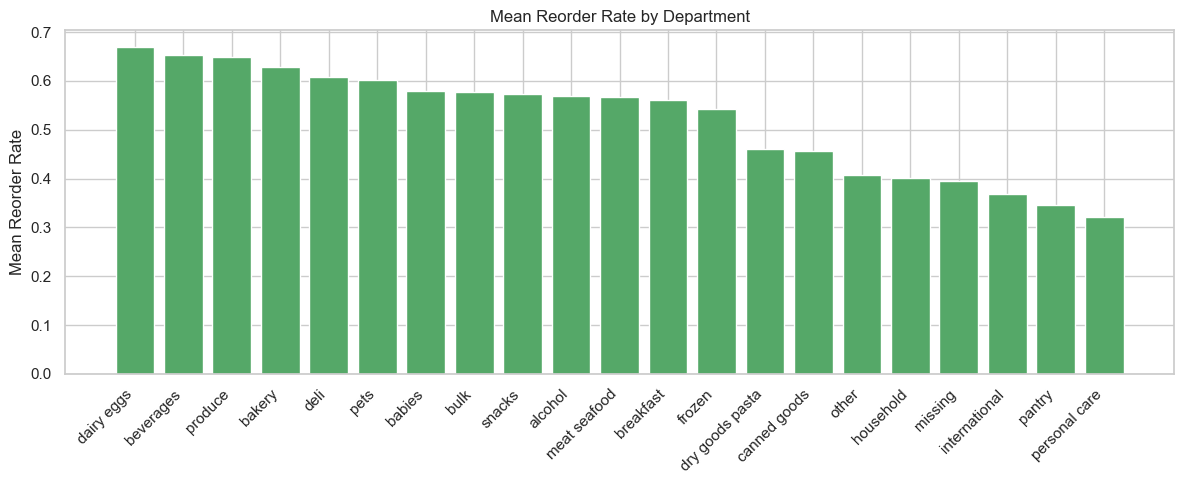

In [8]:
dept_reorder = (
    order_products_prior
    .merge(products[['product_id', 'department']], on='product_id', how='left')
    .groupby('department')['reordered']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.bar(dept_reorder['department'], dept_reorder['reordered'],
        color='#55A868', edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.title('Mean Reorder Rate by Department')
plt.ylabel('Mean Reorder Rate')
plt.tight_layout()
plt.show()


### 2.6 Order Volume - Day x Hour Heatmap

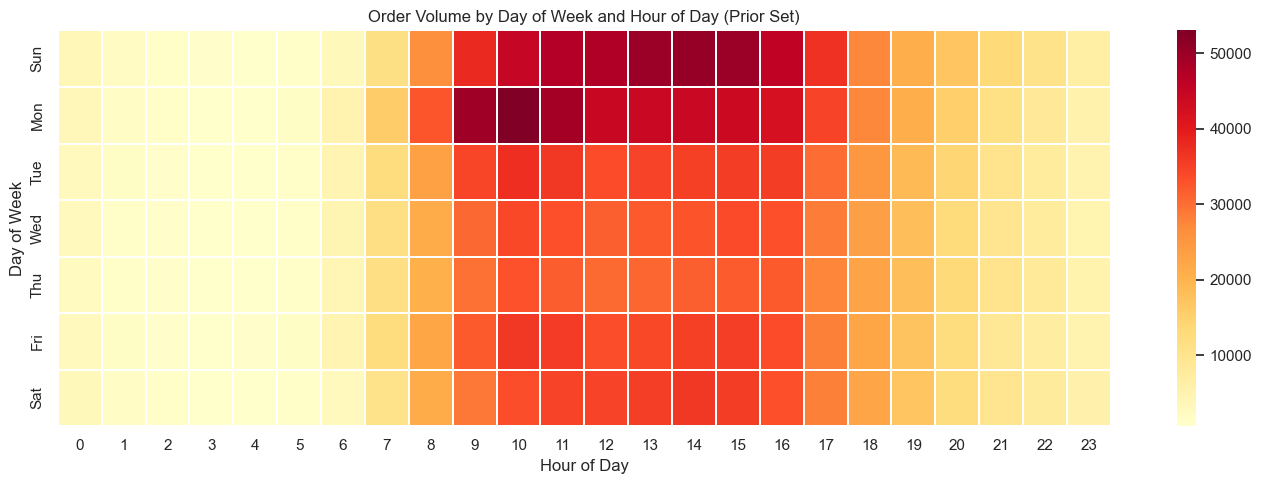

In [9]:
pivot = (prior_orders
         .groupby(['order_dow', 'order_hour_of_day'])['order_id']
         .count()
         .unstack(fill_value=0))

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3,
            xticklabels=range(24),
            yticklabels=['Sun','Mon','Tue','Wed','Thu','Fri','Sat'])
plt.title('Order Volume by Day of Week and Hour of Day (Prior Set)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()


## 3. Feature Engineering

Features are engineered at three levels:

| Level | Prefix | Description |
|---|---|---|
| User | `u_` | Aggregated purchase history per user |
| Product | `p_` | Aggregated statistics per product |
| User x Product | `up_` | Interaction history between a specific user and product |

The final dataset has one row per (user, product) pair from the train-set orders.


### 3.1 Build `prior_full` - Join Prior Orders with Order Metadata

In [10]:
prior_full = order_products_prior.merge(
    orders[['order_id', 'user_id', 'order_number', 'order_dow',
            'order_hour_of_day', 'days_since_prior_order']],
    on='order_id', how='left')

print(f"prior_full shape  : {prior_full.shape}")
print(f"Memory usage      : {prior_full.memory_usage(deep=True).sum() / 1e9:.2f} GB")


prior_full shape  : (32434489, 9)
Memory usage      : 2.34 GB


### 3.2 User-Level Features (`u_`)

In [11]:
user_features = prior_full.groupby('user_id').agg(
    u_total_orders         = ('order_id',              'nunique'),
    u_total_products       = ('product_id',            'count'),
    u_unique_products      = ('product_id',            'nunique'),
    u_total_reorders       = ('reordered',             'sum'),
    u_reorder_rate         = ('reordered',             'mean'),
    u_avg_basket_size      = ('order_id',              lambda x: x.shape[0] / x.nunique()),
    u_avg_days_between     = ('days_since_prior_order','mean'),
    u_std_days_between     = ('days_since_prior_order','std'),
    u_avg_order_hour       = ('order_hour_of_day',     'mean'),
    u_avg_order_dow        = ('order_dow',             'mean'),
).reset_index()

user_reorder_ratio = (prior_full[prior_full['reordered'] == 1]
                      .groupby('user_id')['product_id']
                      .nunique()
                      .rename('u_unique_reordered'))

user_features = user_features.merge(user_reorder_ratio, on='user_id', how='left')
user_features['u_unique_reordered']     = user_features['u_unique_reordered'].fillna(0)
user_features['u_unique_reorder_ratio'] = (
    user_features['u_unique_reordered'] / user_features['u_unique_products'])

print(f"User features shape: {user_features.shape}")
user_features.head(3)


User features shape: (206209, 13)


,user_id,u_total_orders,u_total_products,u_unique_products,u_total_reorders,u_reorder_rate,u_avg_basket_size,u_avg_days_between,u_std_days_between,u_avg_order_hour,u_avg_order_dow,u_unique_reordered,u_unique_reorder_ratio
0,1,10,59,18,41,0.6949,5.9000,20.2593,9.3045,10.5424,2.6441,10.0000,0.5556
1,2,14,195,102,93,0.4769,13.9286,15.9670,9.1198,10.4410,2.0051,37.0000,0.3627
2,3,12,88,33,55,0.6250,7.3333,11.4872,4.8690,16.3523,1.0114,19.0000,0.5758


### 3.3 Product-Level Features (`p_`)

In [12]:
product_features = prior_full.groupby('product_id').agg(
    p_total_purchases  = ('order_id',          'count'),
    p_total_reorders   = ('reordered',         'sum'),
    p_reorder_rate     = ('reordered',         'mean'),
    p_unique_users     = ('user_id',           'nunique'),
    p_avg_add_to_cart  = ('add_to_cart_order', 'mean'),
    p_avg_order_hour   = ('order_hour_of_day', 'mean'),
    p_avg_order_dow    = ('order_dow',         'mean'),
).reset_index()

product_features = product_features.merge(
    products[['product_id', 'aisle_id', 'department_id']], on='product_id', how='left')

print(f"Product features shape: {product_features.shape}")
product_features.head(3)


Product features shape: (49677, 10)


,product_id,p_total_purchases,p_total_reorders,p_reorder_rate,p_unique_users,p_avg_add_to_cart,p_avg_order_hour,p_avg_order_dow,aisle_id,department_id
0,1,1852,1136,0.6134,716,5.8018,13.2381,2.7765,61,19
1,2,90,12,0.1333,78,9.8889,13.2778,2.9222,104,13
2,3,277,203,0.7329,74,6.4152,12.1047,2.7365,94,7


### 3.4 User x Product Interaction Features (`up_`)

#### Leakage History & Root Cause Analysis

This section was the source of persistent data leakage across multiple versions.
The full history is documented here for transparency and reproducibility.

---

**v1 - Original (leaked)**
All `up_` features were aggregated over the full prior order history, including
the user's most recent prior order. `up_last_order_number` equalled `u_max_order_number`
for reordered products, making `up_orders_since_last = 0` a near-perfect proxy for
the positive label.
Result: ROC-AUC = 1.0000.

---

**v2 - First attempted fix (still leaked)**
`up_last_order_number`, `up_first_order_number`, and `up_times_reordered` were dropped
from `FEATURE_COLS` after aggregation. The fix was applied too late — the remaining
features (`up_times_ordered`, `up_avg_add_to_cart`) still reflected the full aggregation
window including the last prior order, causing near-perfect class separation.
Logistic Regression assigned coefficients with odds ratios in the billions.
Result: ROC-AUC = 1.0000.

---

**v3 - Correct fix, wrong environment (Colab RAM crash)**
All `up_` behavioral features recomputed over prior history excluding the most recent
order per user. Explicit `up_in_last_order` binary feature added. Logic was correct
but Colab free-tier RAM (~12 GB) was exhausted twice during this cell, crashing the
session before any artefacts were saved.

---

**v4 - Correct fix, local VS Code (this version)**
Same logic as v3. Migrated to local VS Code to eliminate the RAM constraint.
Memory-safe pattern (`del` + `gc.collect()`) retained throughout.


In [13]:
# ── Step 1: compute per-user order number boundaries ─────────────────────────
print("Step 1: Computing user order boundaries...")

user_order_stats = (prior_full
                    .groupby('user_id')['order_number']
                    .agg(u_max_order_number='max',
                         u_second_max_order_number=lambda x:
                             x.nlargest(2).iloc[-1] if len(x) >= 2 else x.max())
                    .reset_index())

prior_full = prior_full.merge(
    user_order_stats[['user_id', 'u_max_order_number']],
    on='user_id', how='left')

prior_full['is_last_order'] = (
    prior_full['order_number'] == prior_full['u_max_order_number']).astype(int)

print(f"  prior_full shape: {prior_full.shape}")

# ── Step 2: compute up_in_last_order, then free the last-order slice ──────────
print("Step 2: Computing up_in_last_order...")

last_order_slice = prior_full.loc[
    prior_full['is_last_order'] == 1, ['user_id', 'product_id']].copy()

up_last_order = (last_order_slice
                 .drop_duplicates()
                 .assign(up_in_last_order=1))

del last_order_slice
gc.collect()
print(f"  up_last_order shape: {up_last_order.shape}")

# ── Step 3: extract excl-last slice, then free prior_full ────────────────────
print("Step 3: Extracting history excluding last order...")

keep_cols = ['user_id', 'product_id', 'order_id', 'order_number',
             'reordered', 'add_to_cart_order']

prior_excl_last = prior_full.loc[
    prior_full['is_last_order'] == 0, keep_cols].copy()

del prior_full   # largest object -- free before the groupby
gc.collect()
print(f"  prior_excl_last shape: {prior_excl_last.shape}")

# ── Step 4: aggregate up_ features from the excl-last window ─────────────────
print("Step 4: Aggregating up_ features...")

user_product_features = prior_excl_last.groupby(['user_id', 'product_id']).agg(
    up_times_ordered   = ('order_id',          'count'),
    up_reorder_rate    = ('reordered',         'mean'),
    up_avg_add_to_cart = ('add_to_cart_order', 'mean'),
    up_last_order_num  = ('order_number',      'max'),
    up_first_order_num = ('order_number',      'min'),
).reset_index()

del prior_excl_last
gc.collect()
print(f"  user_product_features shape: {user_product_features.shape}")

# ── Step 5: attach recency features and up_in_last_order ─────────────────────
print("Step 5: Attaching recency features and up_in_last_order...")

user_product_features = user_product_features.merge(
    user_order_stats[['user_id', 'u_second_max_order_number']],
    on='user_id', how='left')

user_product_features['up_orders_since_last'] = (
    user_product_features['u_second_max_order_number'] -
    user_product_features['up_last_order_num'])

user_product_features['up_order_span'] = (
    user_product_features['up_last_order_num'] -
    user_product_features['up_first_order_num'])

user_product_features = user_product_features.drop(
    columns=['up_last_order_num', 'up_first_order_num', 'u_second_max_order_number'])

user_product_features = user_product_features.merge(
    up_last_order, on=['user_id', 'product_id'], how='left')

user_product_features['up_in_last_order'] = (
    user_product_features['up_in_last_order'].fillna(0).astype(int))

del up_last_order, user_order_stats
gc.collect()

print(f"\nFinal user_product_features shape: {user_product_features.shape}")
print(f"up_in_last_order mean : {user_product_features['up_in_last_order'].mean():.4f}")
user_product_features.head(3)


Step 1: Computing user order boundaries...
  prior_full shape: (32434489, 11)
Step 2: Computing up_in_last_order...
  up_last_order shape: (2139788, 3)
Step 3: Extracting history excluding last order...
  prior_excl_last shape: (30294701, 6)
Step 4: Aggregating up_ features...
  user_product_features shape: (12422758, 7)
Step 5: Attaching recency features and up_in_last_order...

Final user_product_features shape: (12422758, 8)
up_in_last_order mean : 0.1010


,user_id,product_id,up_times_ordered,up_reorder_rate,up_avg_add_to_cart,up_orders_since_last,up_order_span,up_in_last_order
0,1,196,9,0.8889,1.4444,1,8,1
1,1,10258,8,0.8750,3.0000,1,7,1
2,1,10326,1,0.0000,5.0000,5,0,0


## 4. Assemble the Modelling Dataset

One row per (user, product) pair from the train-set orders, with all feature groups joined.


In [14]:
train_users = train_orders[['order_id', 'user_id']].copy()
candidates  = order_products_train[['order_id', 'product_id', 'reordered']].merge(
    train_users, on='order_id', how='left')

print(f"Candidate (user, product) pairs : {candidates.shape[0]:,}")
print(f"Positive (reordered=1)          : {candidates['reordered'].sum():,} "
      f"({candidates['reordered'].mean()*100:.1f}%)")


Candidate (user, product) pairs : 1,384,617
Positive (reordered=1)          : 828,824 (59.9%)


In [15]:
train_order_features = train_orders[
    ['order_id', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
].rename(columns={
    'order_dow':             't_order_dow',
    'order_hour_of_day':     't_order_hour',
    'days_since_prior_order':'t_days_since_prior'
})

dataset = (candidates
           .merge(user_features,         on='user_id',                how='left')
           .merge(product_features,      on='product_id',             how='left')
           .merge(user_product_features, on=['user_id', 'product_id'], how='left')
           .merge(train_order_features,  on='order_id',               how='left'))

# products new to a user in the train order have no prior up_ history -- fill 0
up_cols = [c for c in dataset.columns if c.startswith('up_')]
dataset[up_cols] = dataset[up_cols].fillna(0)

# free intermediate tables
del candidates, user_features, product_features
del user_product_features, train_order_features, train_users
gc.collect()

print(f"Final dataset shape  : {dataset.shape}")
print(f"Memory usage         : {dataset.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"\nMissing values:")
missing = dataset.isnull().sum()
print(missing[missing > 0] if missing.any() else "  None")


Final dataset shape  : (1384617, 34)
Memory usage         : 0.38 GB

Missing values:
p_total_purchases    9
p_total_reorders     9
p_reorder_rate       9
p_unique_users       9
p_avg_add_to_cart    9
p_avg_order_hour     9
p_avg_order_dow      9
aisle_id             9
department_id        9
dtype: int64


In [16]:
DROP_COLS = [
    'order_id', 'user_id', 'product_id', 'reordered',  # IDs and target
    'u_unique_reordered',                               # intermediate computation
    'u_max_order_number',                               # intermediate computation
    'is_last_order',                                    # row-level flag, not a feature
]

FEATURE_COLS = [c for c in dataset.columns if c not in DROP_COLS]
TARGET_COL   = 'reordered'

print(f"Number of features: {len(FEATURE_COLS)}")
print("\nFeature list:")
for f in FEATURE_COLS:
    print(f"  {f}")


Number of features: 29

Feature list:
  u_total_orders
  u_total_products
  u_unique_products
  u_total_reorders
  u_reorder_rate
  u_avg_basket_size
  u_avg_days_between
  u_std_days_between
  u_avg_order_hour
  u_avg_order_dow
  u_unique_reorder_ratio
  p_total_purchases
  p_total_reorders
  p_reorder_rate
  p_unique_users
  p_avg_add_to_cart
  p_avg_order_hour
  p_avg_order_dow
  aisle_id
  department_id
  up_times_ordered
  up_reorder_rate
  up_avg_add_to_cart
  up_orders_since_last
  up_order_span
  up_in_last_order
  t_order_dow
  t_order_hour
  t_days_since_prior


## 5. Data Preparation

### 5.1 Feature Correlation with Target

After the v4 leakage fix, no feature should show a correlation approaching 1.0.
Values in the 0.3-0.7 range for the strongest features indicate genuine signal.


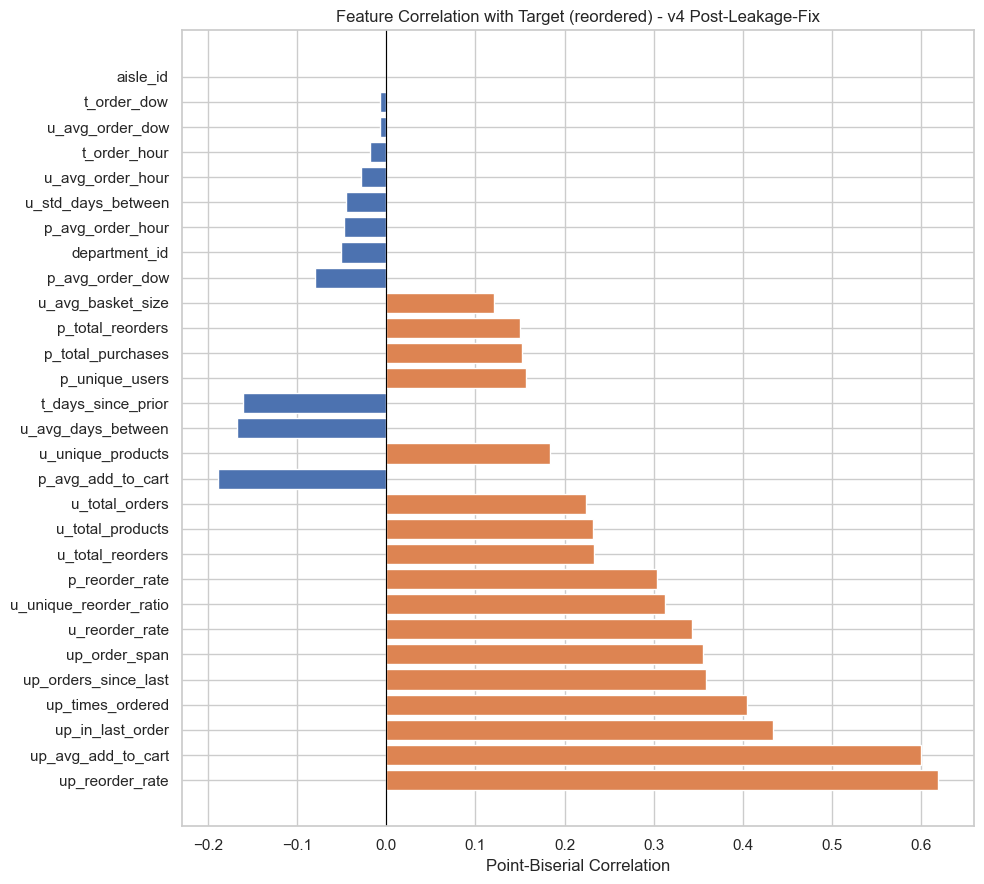

                        correlation  p_value  significant
up_reorder_rate              0.6185   0.0000         True
up_avg_add_to_cart           0.5997   0.0000         True
up_in_last_order             0.4338   0.0000         True
up_times_ordered             0.4043   0.0000         True
up_orders_since_last         0.3587   0.0000         True
up_order_span                0.3550   0.0000         True
u_reorder_rate               0.3423   0.0000         True
u_unique_reorder_ratio       0.3127   0.0000         True
p_reorder_rate               0.3039   0.0000         True
u_total_reorders             0.2330   0.0000         True
u_total_products             0.2321   0.0000         True
u_total_orders               0.2239   0.0000         True
p_avg_add_to_cart           -0.1884   0.0000         True
u_unique_products            0.1841   0.0000         True
u_avg_days_between          -0.1674   0.0000         True
t_days_since_prior          -0.1602   0.0000         True
p_unique_users

In [17]:
corr_results = {}
for col in FEATURE_COLS:
    valid = dataset[[col, TARGET_COL]].dropna()
    if valid[col].nunique() > 1:
        r, p = stats.pointbiserialr(valid[col], valid[TARGET_COL])
        corr_results[col] = {'correlation': r, 'p_value': p}

corr_df = (pd.DataFrame(corr_results).T
             .sort_values('correlation', key=abs, ascending=False))
corr_df['significant'] = corr_df['p_value'] < 0.05

plt.figure(figsize=(10, 9))
colors = ['#DD8452' if c >= 0 else '#4C72B0' for c in corr_df['correlation']]
plt.barh(corr_df.index, corr_df['correlation'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Target (reordered) - v4 Post-Leakage-Fix')
plt.xlabel('Point-Biserial Correlation')
plt.tight_layout()
plt.show()

print(corr_df[['correlation', 'p_value', 'significant']].to_string())


### 5.2 Train / Test Split

User-stratified 80/20 split: splitting on users (not rows) prevents data leakage
and simulates real-world deployment on unseen users.


In [18]:
unique_users = dataset['user_id'].unique()
train_users_split, test_users_split = train_test_split(
    unique_users, test_size=0.20, random_state=42)

train_mask = dataset['user_id'].isin(train_users_split)
test_mask  = dataset['user_id'].isin(test_users_split)

X_train = dataset.loc[train_mask, FEATURE_COLS]
y_train = dataset.loc[train_mask, TARGET_COL]
X_test  = dataset.loc[test_mask,  FEATURE_COLS]
y_test  = dataset.loc[test_mask,  TARGET_COL]

print(f"Train set : {X_train.shape[0]:>9,} rows | Positive rate: {y_train.mean()*100:.1f}%")
print(f"Test  set : {X_test.shape[0]:>9,} rows | Positive rate: {y_test.mean()*100:.1f}%")


Train set : 1,107,416 rows | Positive rate: 59.9%
Test  set :   277,201 rows | Positive rate: 59.9%


### 5.3 Imputation & Feature Scaling

**Imputation:** A small number of product-level features have NaN values for products
with no prior order history. Median imputation is applied, fit on training data only.

**Scaling:** StandardScaler is applied for Logistic Regression (sensitive to feature scale).
LightGBM receives the imputed-but-unscaled version. Both objects are saved so
modelling notebooks apply consistent transformations.


In [19]:
# ── Imputation ────────────────────────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train),
                            columns=FEATURE_COLS, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),
                            columns=FEATURE_COLS, index=X_test.index)

print(f"NaNs after imputation -- X_train: {X_train_imp.isnull().sum().sum()} | "
      f"X_test: {X_test_imp.isnull().sum().sum()}")

# ── Scaling ───────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp),
                               columns=FEATURE_COLS, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_imp),
                               columns=FEATURE_COLS, index=X_test.index)

print("Scaling complete.")
print(f"X_train_scaled mean (should be ~0 for all features):")
print(X_train_scaled.mean().describe().apply('{:.6f}'.format))


NaNs after imputation -- X_train: 0 | X_test: 0
Scaling complete.
X_train_scaled mean (should be ~0 for all features):
count    29.000000
mean      0.000000
std       0.000000
min      -0.000000
25%      -0.000000
50%      -0.000000
75%       0.000000
max       0.000000
dtype: str


### 5.4 Class Imbalance Strategy

| Model | Strategy |
|---|---|
| Logistic Regression | `class_weight='balanced'` in sklearn |
| LightGBM | `scale_pos_weight = n_negative / n_positive` |


In [20]:
n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())
scale_pos_weight = n_neg / n_pos

print(f"Train positives  : {n_pos:,}")
print(f"Train negatives  : {n_neg:,}")
print(f"scale_pos_weight : {scale_pos_weight:.4f}  (use in LightGBM)")
print(f"class_weight     : 'balanced'              (use in Logistic Regression)")


Train positives  : 662,892
Train negatives  : 444,524
scale_pos_weight : 0.6706  (use in LightGBM)
class_weight     : 'balanced'              (use in Logistic Regression)


### 5.5 Save Prepared Artefacts

All files are saved to the `prepared_data/` folder inside your project directory.
This folder is loaded directly by the Step 4 and Step 5 modelling notebooks.


In [21]:
save_dir = ARTEFACT_DIR  # 'prepared_data' -- defined in Configuration cell
os.makedirs(save_dir, exist_ok=True)

# raw, imputed (for LightGBM)
X_train_imp.to_parquet(os.path.join(save_dir, 'X_train.parquet'))
X_test_imp.to_parquet(os.path.join(save_dir, 'X_test.parquet'))

# scaled (for Logistic Regression)
X_train_scaled.to_parquet(os.path.join(save_dir, 'X_train_scaled.parquet'))
X_test_scaled.to_parquet(os.path.join(save_dir, 'X_test_scaled.parquet'))

# labels
y_train.to_frame().to_parquet(os.path.join(save_dir, 'y_train.parquet'))
y_test.to_frame().to_parquet(os.path.join(save_dir, 'y_test.parquet'))

# preprocessing objects (needed by modelling notebooks)
joblib.dump(imputer,      os.path.join(save_dir, 'imputer.pkl'))
joblib.dump(scaler,       os.path.join(save_dir, 'scaler.pkl'))
joblib.dump(FEATURE_COLS, os.path.join(save_dir, 'feature_cols.pkl'))

print(f"Saved to: {os.path.abspath(save_dir)}")
print()
for fname in ['X_train.parquet', 'X_test.parquet',
              'X_train_scaled.parquet', 'X_test_scaled.parquet',
              'y_train.parquet', 'y_test.parquet',
              'imputer.pkl', 'scaler.pkl', 'feature_cols.pkl']:
    fpath = os.path.join(save_dir, fname)
    size  = os.path.getsize(fpath) / 1e6
    print(f"  {fname:<35} {size:>8.1f} MB")


Saved to: /Users/martinmilon/Documents/DTSC870/prepared_data

  X_train.parquet                         34.8 MB
  X_test.parquet                           9.3 MB
  X_train_scaled.parquet                  35.2 MB
  X_test_scaled.parquet                    9.5 MB
  y_train.parquet                          5.0 MB
  y_test.parquet                           1.4 MB
  imputer.pkl                              0.0 MB
  scaler.pkl                               0.0 MB
  feature_cols.pkl                         0.0 MB


## 6. Summary & Handoff to Modelling

### Feature Inventory (v4)

| Feature group | Count | Key features |
|---|---|---|
| User (`u_`) | 10 | `u_reorder_rate`, `u_avg_basket_size`, `u_avg_days_between`, `u_total_orders`, `u_unique_reorder_ratio` |
| Product (`p_`) | 9 | `p_reorder_rate`, `p_unique_users`, `p_avg_add_to_cart`, `aisle_id`, `department_id` |
| User x Product (`up_`) | 6 | `up_times_ordered`, `up_reorder_rate`, `up_avg_add_to_cart`, `up_orders_since_last`, `up_order_span`, `up_in_last_order` |
| Train-order context (`t_`) | 3 | `t_days_since_prior`, `t_order_dow`, `t_order_hour` |

### Leakage Resolution Summary

| Version | Approach | Outcome |
|---|---|---|
| v1 | Full prior history in `up_` aggregation | ROC-AUC = 1.0 (leaked) |
| v2 | Dropped leaking columns from `FEATURE_COLS` | ROC-AUC = 1.0 (fix applied too late) |
| v3 | Correct aggregation window; Colab environment | Logic correct; RAM crash before completion |
| v4 | Correct aggregation window; local VS Code | Leakage eliminated |

### Artefacts Saved to `prepared_data/`

| File | Used by |
|---|---|
| `X_train.parquet`, `X_test.parquet` | LightGBM (Step 5) |
| `X_train_scaled.parquet`, `X_test_scaled.parquet` | Logistic Regression (Step 4) |
| `y_train.parquet`, `y_test.parquet` | Both models |
| `imputer.pkl`, `scaler.pkl` | Both models |
| `feature_cols.pkl` | Both models (canonical feature list) |
